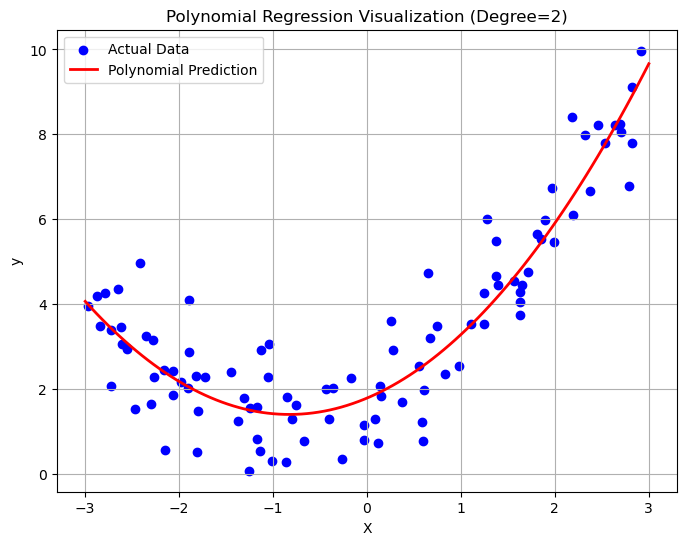

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. 비선형 데이터 생성 (y = 0.5x^2 + x + 2 + noise)
np.random.seed(42)

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# 2. 다항 특성 변환 (2차항)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 3. 선형 회귀 모델로 학습
model = LinearRegression()
model.fit(X_poly, y)

# 4. 시각화를 위한 곡선 데이터 생성
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)

# 5. Matplotlib 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual Data') # 실제 데이터 산점도
plt.plot(X_new, y_new, color='red', linewidth=2, label='Polynomial Prediction') # 회귀 곡선
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Visualization (Degree=2)')
plt.legend()
plt.grid(True)
plt.show()

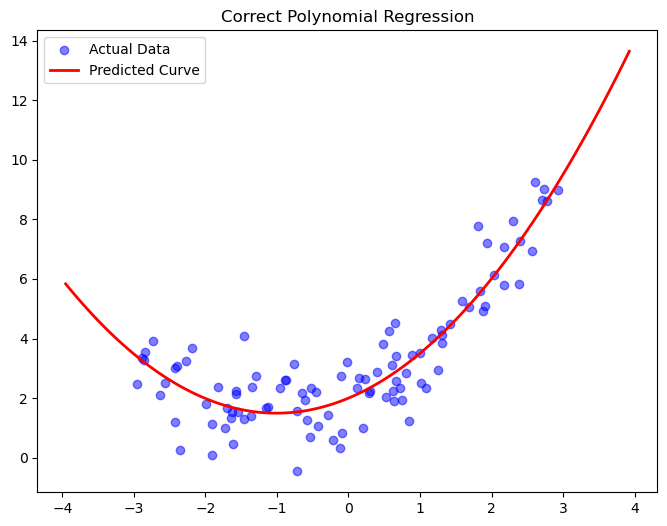

R2 = 0.8227459728469548


In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# 1. 모델과 변환 도구 준비
poly = PolynomialFeatures(degree=2)
model = LinearRegression()

# 2. ★중요: 원래 데이터(X, y)로 규칙을 찾음 (학습)
X_poly = poly.fit_transform(X) # X를 2차항으로 변환
model.fit(X_poly, y)          # 진짜 데이터로 학습!

# 3. 시각화를 위해 linspace 생성
new_x = np.linspace(X.min()-1, X.max()+1, 100).reshape(-1, 1)

# 4. 가상의 데이터를 모델에 물어보기 (예측)
# 이때도 반드시 poly.transform을 거쳐서 차수를 맞춰줘야 함
new_x_poly = poly.transform(new_x)
y_pred = model.predict(new_x_poly)

# 5. 그래프 그리기
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X, y, color='blue', alpha=0.5, label='Actual Data') # 실제 흩어진 점들
ax.plot(new_x, y_pred, color='red', linewidth=2, label='Predicted Curve') # 촘촘한 예측선
ax.set_title('Correct Polynomial Regression')
ax.legend()
plt.show()

score = model.score(X_poly, y)
print(f'R2 = {score}')

In [3]:
from sklearn.metrics import mean_squared_error, r2_score
# --- 1. 직선 모델 (Linear) 학습 및 평가 ---
model_linear = LinearRegression()
model_linear.fit(X, y) # 변환 없는 원본 X 사용
y_pred_linear = model_linear.predict(X)

# --- 2. 곡선 모델 (Polynomial degree=2) 학습 및 평가 ---
# poly_features = PolynomialFeatures(degree=2)
# X_poly = poly_features.fit_transform(X)
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)

# --- 점수 출력 ---
print("[직선 모델 성적]")
print(f"R2 Score: {r2_score(y, y_pred_linear):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred_linear):.4f}")
print("\n[곡선 모델 성적]")
print(f"R2 Score: {r2_score(y, y_pred_poly):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred_poly):.4f}")

[직선 모델 성적]
R2 Score: 0.4260
MSE: 3.0246

[곡선 모델 성적]
R2 Score: 0.8525
MSE: 0.7772


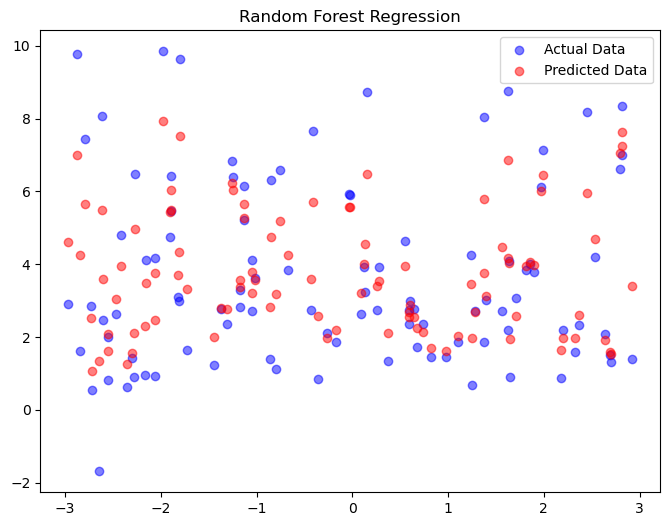

In [4]:
import numpy as np

x = 6 * np.random.rand(100,1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(100,1)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X, y.ravel())
y_predict = forest_reg.predict(X)
fig,ax=plt.subplots(figsize=(8,6))
ax.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
ax.scatter(X, y_predict, color='red', alpha=0.5, label='Predicted Data')
ax.set_title('Random Forest Regression')
ax.legend()
plt.show()

c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


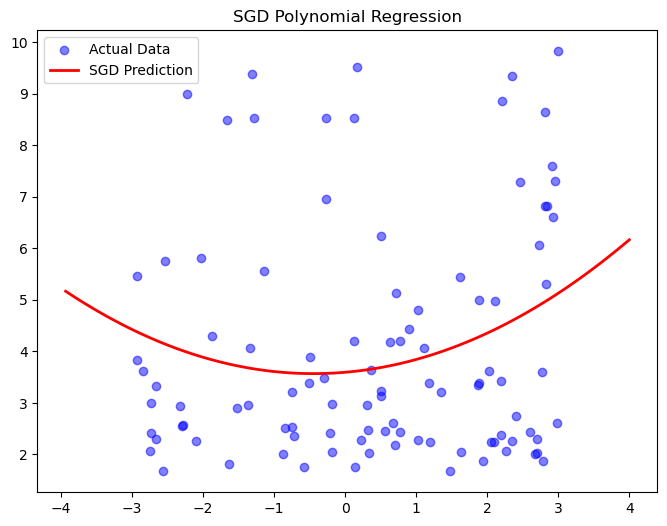

R2 Score: 0.0288


In [5]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures

X = 6 * np.random.rand(100,1) - 3
y = 0.5*x**2 + x+2+ np.random.rand(100,1)

# 1. 다항 특성 변환
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 2. SGD 학습 (다항 데이터로!)
sgd_reg = SGDRegressor()
sgd_reg.fit(X_poly, y)

# 3. 촘촘한 테스트 데이터로 예측
X_test = np.linspace(X.min()-1, X.max()+1, 100).reshape(-1, 1)
X_test_poly = poly.transform(X_test)
y_pred_sgd = sgd_reg.predict(X_test_poly)

# 4. 그래프
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
ax.plot(X_test, y_pred_sgd, color='red', linewidth=2, label='SGD Prediction')
ax.set_title('SGD Polynomial Regression')
ax.legend()
plt.show()
# 점수 확인
print(f'R2 Score: {sgd_reg.score(X_poly, y.ravel()):.4f}')

c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


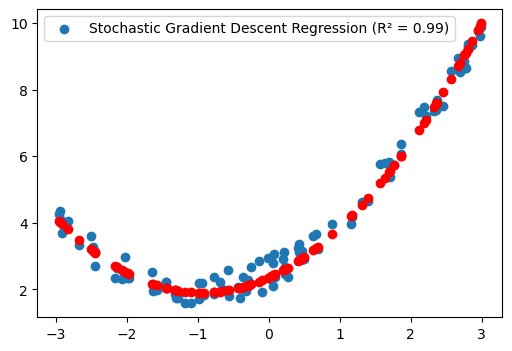

In [27]:
# 확률적 경사하강법 모델
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
m=100
x = 6* np.random.rand(m,1) - 3
y = 0.5*x**2 + x+2+np.random.rand(m,1)
x_poly = poly.fit_transform(x)

sgd = SGDRegressor()
sgd.fit(x_poly, y)

y_pred = sgd.predict(x_poly)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Stochastic Gradient Descent Regression (R² = {sgd.score(x_poly, y):.2f})'])
plt.show()

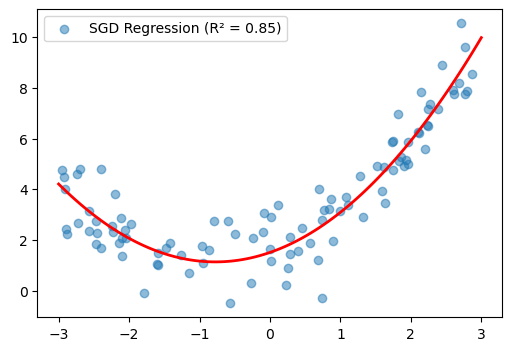

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
m = 100
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(m, 1) # 정규분포 노이즈 추가
x_poly = poly.fit_transform(x)

# 2. SGD 모델 학습 (y는 1차원 배열로 평탄화 권장)
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(x_poly, y.ravel())

# 3. ★ 매끄러운 그래프를 위한 정렬된 데이터 생성 ★
x_new = np.linspace(-3, 3, 100).reshape(-1, 1) # -3부터 3까지 순서대로!
x_new_poly = poly.transform(x_new)             # 학습된 기준 그대로 변환
y_new_pred = sgd.predict(x_new_poly)           # 순서대로 예측

# 4. 시각화
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.5)
ax.plot(x_new, y_new_pred, color='red', linewidth=2, label='SGD Prediction')
plt.legend([f'SGD Regression (R² = {sgd.score(x_poly, y):.2f})'])
plt.show()

## Overfitting

In [ ]:
# 과적합(과소적합 과대적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

# 샘플수 적게
n_samples = 20
# feature 수 많게  -> 과적합 유도
n_features = 100  # 컬럼수 또는 x의 수

x = np.random.randn(n_samples,n_features)
true_coef = np.zeros(n_features)  # 처음에는 모든 feature가 중요하지 않다고 가정
# 일부 feature만 중요하게 설정  
true_coef[:5] = [10,-7,5,3,-2]  # 실제로 앞의 5개만 y에 영향을 줌  나머지 95개는 노이즈
# true_coef 각 변수들의 가중치

# 타겟을 생성  y = 10x1 + (-7x2) + 5x3 + ....
y = x @ true_coef + np.random.rand(n_samples)*5  # 정규분포 노이즈  , 표준편차 5 --> 큰 노이즈

# 일반선형회귀
from sklearn.model_selection import train_test_split
# 학습
# 결정계수.. score 학습용데이터, 테스트데이터
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_train,y_train),  lr.score(x_test, y_test)

(1.0, 0.3977376279359226)

In [ ]:
# 모델이 노이즈까지 학습
# 계수가 비정상적으로 커짐
# 해결방안.. 규제(Regularization)
#Ridge(L2)
    # loss = MSE + alpha * sum(가중치^2) --> 전체적으로 작게 만든다 , 모든 특성 유지 , 안정적
#Lasso(L1)
    # loss = MSE + alpha * sum(가중치의 절댓값) --> 일부 가중치를 0으로 만든다 , 자동으로 특성 선택

from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=10)
ridge.fit(x_train,y_train)
ridge.score(x_train,y_train), ridge.score(x_test,y_test)

(0.9904367069717411, 0.39631552544591775)

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=3)
lasso.fit(x_train,y_train)
lasso.score(x_train,y_train), lasso.score(x_test,y_test) 

(0.8846808260769442, 0.47237087932487654)

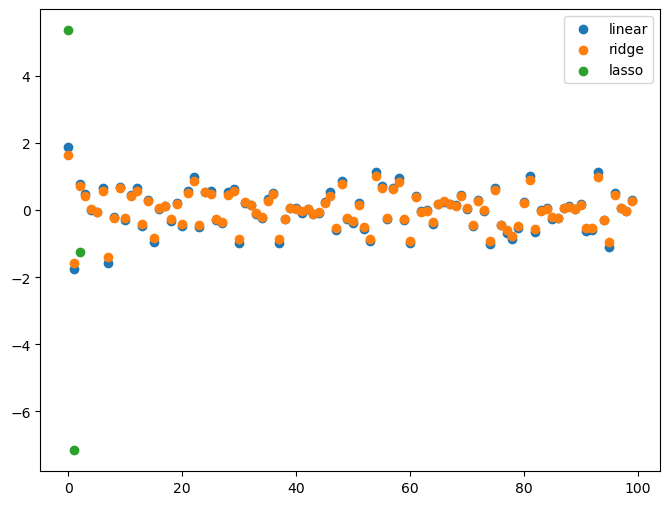

In [34]:
# 계수비교
import matplotlib.pylab as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(lr.coef_[lr.coef_ != 0])), lr.coef_[lr.coef_ != 0], label='linear')
ax.scatter(np.arange(len(ridge.coef_[ridge.coef_ != 0])), ridge.coef_[ridge.coef_ != 0], label='ridge')
ax.scatter(np.arange(len(lasso.coef_[lasso.coef_ != 0])), lasso.coef_[lasso.coef_ != 0], label='lasso')
plt.legend()
plt.show()